# M6.5 — Camera/diffusion matrix and idempotent delta execution

Plan: [`plans/milestone_06/06_sequence_generation_plan.md`](../../plans/milestone_06/06_sequence_generation_plan.md).

Demonstrates per-sequence output reconciliation, shared M6.4 source caches, downstream matrix sweeps, identical-rerun no-op behavior, and added-row delta generation. All orchestration logic lives in `gummybear.datasets`; this notebook only coordinates and displays it.

Workbook: `configs/m6/m6_matrix_plan.xlsx` → outputs under `data/generated/m6_5/`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem,dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import pandas as pd
from IPython.display import display

from gummybear.datasets import (
    build_execution_plan,
    build_output_delta_plan,
    load_generation_workbook,
    run_generation_plan,
    validate_generation_plan,
)
import gummybear_validation.milestone_06.validation as m6_validation
from gummybear_validation.milestone_06 import (
    enable_sequence_in_workbook_copy,
    inspect_cache_plan,
    inspect_output_delta_plan,
    load_sequence_manifest,
    matrix_jobs_summary_table,
    preview_sequence_roles,
    validate_generated_sequence,
)
from gummybear_validation.notebook_tools import run_installed_pytest_tests

WORKBOOK_PATH = ROOT / "configs" / "m6" / "m6_matrix_plan.xlsx"
OUTPUT_ROOT = ROOT / "data" / "generated" / "m6_5"
CACHE_ROOT = OUTPUT_ROOT / "_cache"


In [3]:
workbook = load_generation_workbook(WORKBOOK_PATH)
plan = validate_generation_plan(workbook, repo_root=ROOT)
job_rows = matrix_jobs_summary_table(plan.jobs)
display(job_rows)
assert job_rows["clean_cache_id"].nunique() == 1
assert job_rows["particle_cache_id"].nunique() == 1
print(f"Workbook: {display_path(WORKBOOK_PATH)}")


,sequence_id,resolved_job_hash,clean_cache_id,particle_cache_id,diffusion_setup_id,extrapolation_length,camera_schedule_id,frames
0,bear_m6_matrix_001,fae3de81a209cbffbb3bd7b783c73f0ce9a357b5efd23c...,83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c...,fc8d18d4bab4140eab2144ce820045ef2dfb7becf2160e...,diff_matrix_robin_l05,5.0,orbit_matrix_006,6
1,bear_m6_matrix_002,d48fbb67bc3fd96952287aac68edb4c2d80e14bc27ecab...,83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c...,fc8d18d4bab4140eab2144ce820045ef2dfb7becf2160e...,diff_matrix_robin_l05,5.0,orbit_matrix_012,12
2,bear_m6_matrix_003,33d6ad904248ad8bad018b2c567dcd29960bb73cfb0859...,83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c...,fc8d18d4bab4140eab2144ce820045ef2dfb7becf2160e...,diff_matrix_robin_l12,12.0,orbit_matrix_012,12


Workbook: configs/m6/m6_matrix_plan.xlsx


In [4]:
output_delta = build_output_delta_plan(
    plan.jobs,
    output_root=OUTPUT_ROOT,
    disabled_sequence_ids=plan.disabled_sequence_ids,
)
display(pd.DataFrame(inspect_output_delta_plan(output_delta)))
output_delta.require_safe_generation()


,category,sequence_id,status,reason,output_path,details
0,requested,bear_m6_matrix_001,output_missing,sequence_directory_not_found,data/generated/m6_5/bear_m6_matrix_001,{}
1,requested,bear_m6_matrix_002,output_missing,sequence_directory_not_found,data/generated/m6_5/bear_m6_matrix_002,{}
2,requested,bear_m6_matrix_003,output_missing,sequence_directory_not_found,data/generated/m6_5/bear_m6_matrix_003,{}
3,disabled,bear_m6_matrix_004,output_disabled_not_run,workbook_row_disabled,data/generated/m6_5/bear_m6_matrix_004,{}


In [5]:
execution = build_execution_plan(
    plan,
    cache_root=CACHE_ROOT,
    output_root=OUTPUT_ROOT,
    reconcile_outputs=True,
)
display(inspect_cache_plan(execution))
print("Only output_missing jobs appear in these source-cache groups.")


{'workbook_path': 'configs/m6/m6_matrix_plan.xlsx',
 'workbook_sha256': '061ef2523acf9a749632d41ddb14043198106798539d6f885a2b68c4dc89ad4b',
 'cache_root': 'data/generated/m6_5/_cache',
 'plans_diffusion_operator_cache': False,
 'clean_groups': [{'optical_setup_id': 'opt_matrix_backlight_001',
   'clean_optical_cache_id': '83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c5b5d2a5fad27e6a521',
   'cache_status': 'miss',
   'particle_groups': [{'particle_setup_id': 'particle_matrix_sphere_001',
     'particle_group_id': 'particle_matrix_sphere_001',
     'particle_count': 1,
     'particle_source_cache_id': 'fc8d18d4bab4140eab2144ce820045ef2dfb7becf2160e29bfee40f6e6cc4132',
     'cache_status': 'miss',
     'diffusion_groups': [{'diffusion_setup_id': 'diff_matrix_robin_l05',
       'job_count': 2,
       'frame_count': 18,
       'provenance': {'D': 0.8333333333333333,
        'D_source': 'optical_material_diffusion_coefficient',
        'alpha_direct': 0.0,
        'diffusion_setup_id': 'dif

Only output_missing jobs appear in these source-cache groups.


In [6]:
first_run = run_generation_plan(
    execution,
    output_root=OUTPUT_ROOT,
    max_workers=1,
    verbose=True,
)
display(pd.DataFrame([item.to_dict() for item in first_run.output_items]))
print("Generated:", [item.sequence_id for item in first_run.generated])
print("Skipped:  ", list(first_run.skipped))


,sequence_id,output_path,status,reason,details
0,bear_m6_matrix_001,data/generated/m6_5/bear_m6_matrix_001,output_missing,sequence_directory_not_found,{}
1,bear_m6_matrix_002,data/generated/m6_5/bear_m6_matrix_002,output_missing,sequence_directory_not_found,{}
2,bear_m6_matrix_003,data/generated/m6_5/bear_m6_matrix_003,output_missing,sequence_directory_not_found,{}
3,bear_m6_matrix_004,data/generated/m6_5/bear_m6_matrix_004,output_disabled_not_run,workbook_row_disabled,{}


Generated: ['bear_m6_matrix_001', 'bear_m6_matrix_002', 'bear_m6_matrix_003']
Skipped:   []


In [7]:
second_run = run_generation_plan(
    execution,
    output_root=OUTPUT_ROOT,
    max_workers=1,
    verbose=True,
)
requested_second = [
    item for item in second_run.output_items
    if item.sequence_id in {job.sequence_id for job in plan.jobs}
]
display(pd.DataFrame([item.to_dict() for item in requested_second]))
assert second_run.generated == ()
assert all(item.status == "output_complete_current" for item in requested_second)
print("Identical rerun is a no-op: no source, diffusion, or camera physics ran.")


,sequence_id,output_path,status,reason,details
0,bear_m6_matrix_001,data/generated/m6_5/bear_m6_matrix_001,output_complete_current,manifest_and_role_files_match,{}
1,bear_m6_matrix_002,data/generated/m6_5/bear_m6_matrix_002,output_complete_current,manifest_and_role_files_match,{}
2,bear_m6_matrix_003,data/generated/m6_5/bear_m6_matrix_003,output_complete_current,manifest_and_role_files_match,{}


Identical rerun is a no-op: no source, diffusion, or camera physics ran.


## Added-row delta

Enable `bear_m6_matrix_004` on a temporary workbook copy (canonical workbook stays reproducible). Unchanged jobs keep the same `resolved_job_hash`; only the new sequence is generated.


In [8]:
temp_workbook = enable_sequence_in_workbook_copy(
    WORKBOOK_PATH,
    OUTPUT_ROOT / "_workbooks" / "m6_matrix_plan_row004_enabled.xlsx",
    "bear_m6_matrix_004",
    enabled=True,
)
delta_workbook = load_generation_workbook(temp_workbook)
delta_plan = validate_generation_plan(delta_workbook, repo_root=ROOT)
old_hashes = {job.sequence_id: job.resolved_job_hash for job in plan.jobs}
new_hashes = {job.sequence_id: job.resolved_job_hash for job in delta_plan.jobs}
assert all(new_hashes[key] == value for key, value in old_hashes.items())

delta_execution = build_execution_plan(
    delta_plan,
    cache_root=CACHE_ROOT,
    output_root=OUTPUT_ROOT,
    reconcile_outputs=True,
)
display(pd.DataFrame([item.to_dict() for item in delta_execution.output_items]))
delta_run = run_generation_plan(
    delta_execution, output_root=OUTPUT_ROOT, max_workers=1, verbose=True
)
assert [item.sequence_id for item in delta_run.generated] in [[], ["bear_m6_matrix_004"]]
print("Delta generated:", [item.sequence_id for item in delta_run.generated])


,sequence_id,output_path,status,reason,details
0,bear_m6_matrix_001,data/generated/m6_5/bear_m6_matrix_001,output_complete_current,manifest_and_role_files_match,{}
1,bear_m6_matrix_002,data/generated/m6_5/bear_m6_matrix_002,output_complete_current,manifest_and_role_files_match,{}
2,bear_m6_matrix_003,data/generated/m6_5/bear_m6_matrix_003,output_complete_current,manifest_and_role_files_match,{}
3,bear_m6_matrix_004,data/generated/m6_5/bear_m6_matrix_004,output_missing,sequence_directory_not_found,{}


Delta generated: ['bear_m6_matrix_004']


,sequence_id,ok,frame_count,manifest_schema_version,checked_file_count
0,bear_m6_matrix_001,True,6,1.6-m6-draft,43
1,bear_m6_matrix_002,True,12,1.6-m6-draft,85
2,bear_m6_matrix_003,True,12,1.6-m6-draft,85
3,bear_m6_matrix_004,True,6,1.6-m6-draft,43


{'sequence_id': 'bear_m6_matrix_001',
 'resolved_job_hash': 'fae3de81a209cbffbb3bd7b783c73f0ce9a357b5efd23c5888577c9c4fdb546e',
 'cache_ids': {'clean': '83b9d7a583728c38f41e3a12e1a6e68e8da19ce0e33a7c5b5d2a5fad27e6a521',
  'particle': 'fc8d18d4bab4140eab2144ce820045ef2dfb7becf2160e29bfee40f6e6cc4132'},
 'diffusion': {'D': 0.8333333333333333,
  'D_source': 'optical_material_diffusion_coefficient',
  'alpha_direct': 0.0,
  'diffusion_setup_id': 'diff_matrix_robin_l05',
  'extrapolation_length': 5.0,
  'fem_order': 1,
  'g': 0.0,
  'g_source': 'diffusion_setup',
  'mu_a': 0.1,
  'mu_a_source': 'optical_setup',
  'optical_setup_id': 'opt_matrix_backlight_001',
  'provenance_kind': 'diffusion_settings',
  'robin_boundary_model': 'effective_refractive_boundary',
  'solver_tolerance': 1e-08},
 'frame_count': 6}

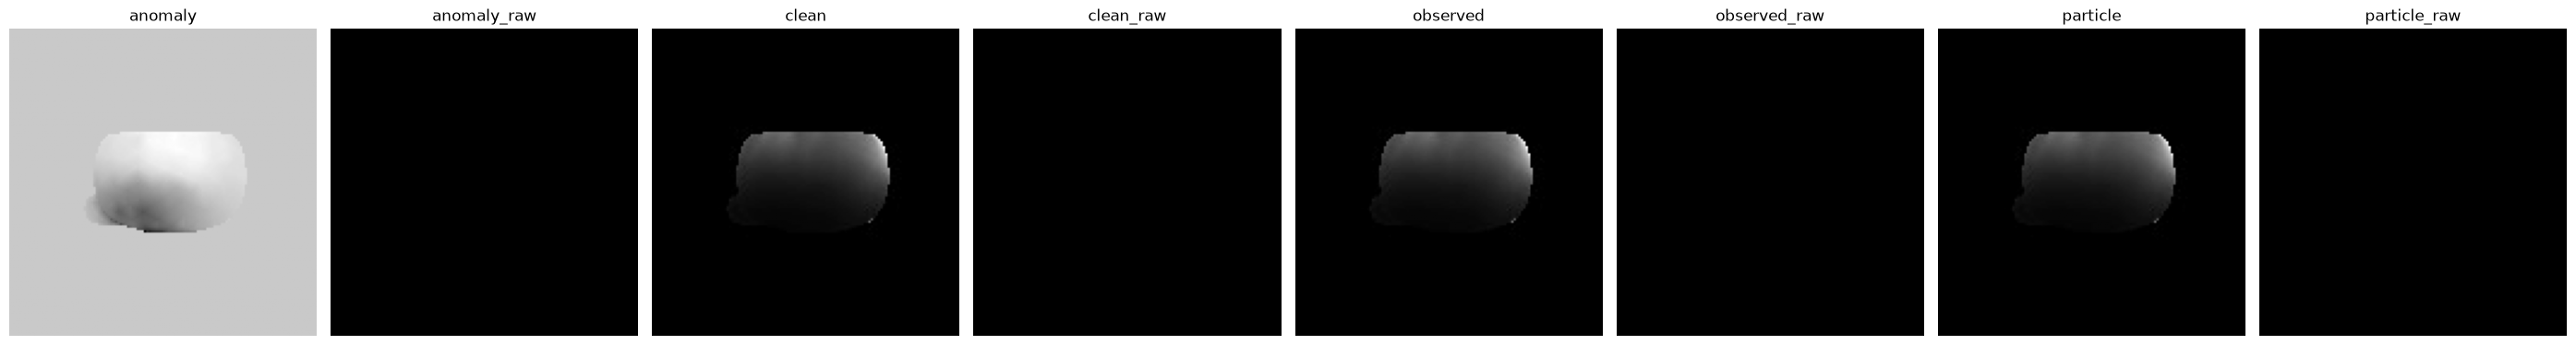

In [9]:
preview_id = plan.jobs[0].sequence_id
preview_sequence_roles(OUTPUT_ROOT / preview_id)

validation_rows = []
for job in delta_plan.jobs:
    sequence_dir = OUTPUT_ROOT / job.sequence_id
    if sequence_dir.is_dir():
        result = validate_generated_sequence(sequence_dir)
        validation_rows.append(result.summary())
        assert result.ok, result.errors

display(pd.DataFrame(validation_rows)[
    ["sequence_id", "ok", "frame_count", "manifest_schema_version", "checked_file_count"]
])
manifest = load_sequence_manifest(OUTPUT_ROOT / preview_id)
{
    "sequence_id": manifest["sequence_id"],
    "resolved_job_hash": manifest["resolved_job_hash"],
    "cache_ids": {
        "clean": manifest["caches"]["clean_optical_cache_id"],
        "particle": manifest["caches"]["particle_source_cache_id"],
    },
    "diffusion": manifest["setups"]["diffusion"]["effective"],
    "frame_count": len(manifest["frames"]),
}


## Installed-package contract checks

Packaged M6.3/M6.4 artifact and cache-contract tests (no FEM). Full matrix orchestration is exercised above via package APIs.


In [10]:
run_installed_pytest_tests(
    m6_validation,
    (
        "test_generated_sequence_artifact_contract",
        "test_source_cache_roundtrip_and_mesh_alignment",
    ),
)


Milestone 6.3
Test executed: test_generated_sequence_artifact_contract()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_06/validation.py . [100%]
============================== 1 passed in 1.05s ===============================

Test proves: A coherent historical M6.2 sequence (persistent_cache_used=False) passes manifest,
             filename, role-alignment, portability, provenance, and decoded-image validation.
Milestone 6.4
Test executed: test_source_cache_roundtrip_and_mesh_alignment()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_06/validation.py . [100%]
============================== 1 passed in 0.81s ===============================

Test proves: A completed numeric source-cache pair is reusable only with matching key, schema,
             required arrays, and diffusion-mesh alignment.
